# Capa 3 — Coverage(t): modelo de cobertura glucocorticoide

Este script implementa dos variantes del mismo modelo PK simplificado de
cobertura glucocorticoide exógena (Coverage(t)):

1. **Modelo A (pauta estándar)**: dosis fijas 10-5-5 mg a horas predefinidas.
2. **Modelo B (pauta real)**: dosis y horas reales extraídas del formulario
   "Tomas_hidrocortisona_20260830.xlsx" (hoja `Respuestas de formulario 2`).

Ambos modelos comparten el mismo núcleo PK (superposición de dosis con
cinética de un compartimento, absorción y eliminación de primer orden).

**Unidades:** Coverage(t) se expresa directamente como tasa, en mg/h de hidrocortisona, la misma unidad que Demand(t) (producción de cortisol), no en concentración plasmática real (mg/L) ni en una escala relativa [0,1]. Es condición necesaria para que Risk(t) = Demand(t) − Coverage(t) tenga sentido dimensional en la capa 4. Coverage(t) NO se normaliza por defecto — ver notas metodológicas al final.

# 0. Imports
Se importan las librerías necesarias: `numpy` y `pandas` para el cálculo numérico, `matplotlib` para
las visualizaciones, y `dataclass`/`Path` de la librería estándar para la definición de parámetros y
el manejo de rutas.

In [1]:
from __future__ import annotations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass
from pathlib import Path

# 1. Núcleo PK compartido

Modelo de un compartimento con absorción oral de primer orden (Bateman). La cantidad de hidrocortisona en el organismo tras una toma de dosis D (mg) en t = 0 es

$$X(t) = D\,\frac{k_a}{k_a-k_e}\left(e^{-k_e t}-e^{-k_a t}\right),\qquad t\ge 0\quad[\text{mg}]$$

y Coverage(t) se define como la tasa de eliminación aparente: el producto del aclaramiento (CL = ke·Vd) por la concentración C(t) = X(t)/Vd,

$$\text{Coverage}(t)=k_e\,X(t)=k_e\,D\,\frac{k_a}{k_a-k_e}\left(e^{-k_e t}-e^{-k_a t}\right)\quad[\text{mg/h}]$$

El volumen de distribución se cancela, por lo que no hace falta estimarlo. La integral de una toma es igual a su dosis D, y con 20 mg al día la media diaria es 20/24 = 0,833 mg/h. La definición presupone la convención de estado estacionario (producción = eliminación) que también usa D_ref: durante la absorción, la tasa de eliminación aparente retrasa la de entrada. No es una concentración plasmática real.

Valores por defecto — derivación:

ke y ka se derivan AMBOS de los dos únicos valores que
Derendorf et al. (1991) sí reportan explícitamente para hidrocortisona
oral: t1/2 (semivida de eliminación) y tmax (instante del pico
observado). Cadena de derivación:

  1. ke = ln(2) / t1/2, con t1/2 = 1.7 h (Derendorf et al., 1991)
     → ke ≈ 0.4077 h^-1. Cálculo directo, una sola variable.

  2. ka se resuelve NUMÉRICAMENTE (la ecuación tmax=ln(ka/ke)/(ka-ke) no
     tiene solución cerrada en ka) de forma que, junto con el ke ya
     fijado, reproduzca tmax = 1.25 h — el punto medio del rango
     observado por Derendorf (1-1.5 h) — en vez de "elegir" un ka y
     comprobar después si el tmax resultante cae dentro del rango
     (lo cual no es una derivación, es una coincidencia comprobada a
     posteriori). Resultado: ka ≈ 1.3874 h^-1.

Con esto, ambos parámetros quedan anclados a cifras que Derendorf et al.
(1991) reportan directamente, sin ningún valor introducido "a ojo".
Sigue siendo una aproximación de literatura general, no calibrada a esta
paciente — eso no cambia y se gestiona con el análisis de sensibilidad
Monte Carlo (Sección 6).

Se importan las tres funciones que constituyen el modelo farmacocinético base, definidas en
`formulario_utils.py` como módulo compartido: `PKParams` (contenedor de `ka`/`ke`), `bateman_single_dose()`
(contribución de una única toma, modelo de Bateman de un compartimento) y `compute_coverage()`
(superposición lineal de todas las tomas sobre una rejilla temporal, en mg/hora).

In [2]:
from formulario_utils import PKParams, bateman_single_dose, compute_coverage

## 1.1. Interpretación visual de los parámetros del modelo PK

Qué representa cada símbolo de Coverage(t) = ke·D·(ka/(ka−ke))·(e^(−ke·t) − e^(−ka·t)):

- **D** — dosis (mg). Escala la altura de la curva (una toma de 10 mg genera una curva el doble de alta que una de 5 mg) pero **no cambia el instante del pico** (tmax es el mismo).
- **ka (h⁻¹)** — constante de velocidad de absorción. Gobierna la
  pendiente de subida: cuanto mayor ka, más deprisa se alcanza el pico
  tras la toma.
- **ke (h⁻¹)** — constante de velocidad de eliminación. Gobierna la
  pendiente de la fase final de bajada; de ella se deriva la semivida
  t½ = ln(2)/ke. Además, al ser Coverage(t) = ke·X(t), ke también multiplica la amplitud de la curva, sin desplazar tmax
- **tmax (h)** — instante del pico de Coverage(t), derivado
  analíticamente de ka y ke: tmax = ln(ka/ke)/(ka−ke). No es un parámetro
  libre, es una consecuencia de los otros dos.
- **Cmax (mg/h)** — valor de Coverage(t) en tmax. Escala linealmente con D.
- **t½ (h)** — tiempo que tarda Coverage(t) en reducirse a la mitad, una
  vez la curva entra en fase de eliminación pura (lejos de tmax, cuando
  el término e^(−ka·t) ya es despreciable frente a e^(−ke·t)). Por eso
  se mide aquí en un punto avanzado (t=6h), no justo después del pico:
  cerca de tmax la curva todavía mezcla absorción y eliminación y no es
  una exponencial pura — usar t½ ahí daría un resultado engañoso.

El panel derecho usa escala semi-logarítmica porque, en fase de
eliminación pura, Coverage(t) ≈ ke·D·(ka/(ka−ke))·e^(−ke·t): una exponencial se ve
como una recta en escala log, y su pendiente es directamente −ke — la
misma lógica que un gráfico semi-log de decaimiento radiactivo.

**Conclusión:** el gráfico confirma visualmente el comportamiento esperado del modelo: la dosis
escala la altura de la curva sin desplazar el instante del pico (tmax idéntico para 10mg y 5mg), y
la fase de eliminación se aproxima a una línea recta en escala semi-logarítmica, la firma
característica de un decaimiento exponencial de primer orden gobernado por ke. El modelo se comporta
tal como predice su formulación analítica, antes de emplearlo para superponer múltiples tomas en las
siguientes secciones.

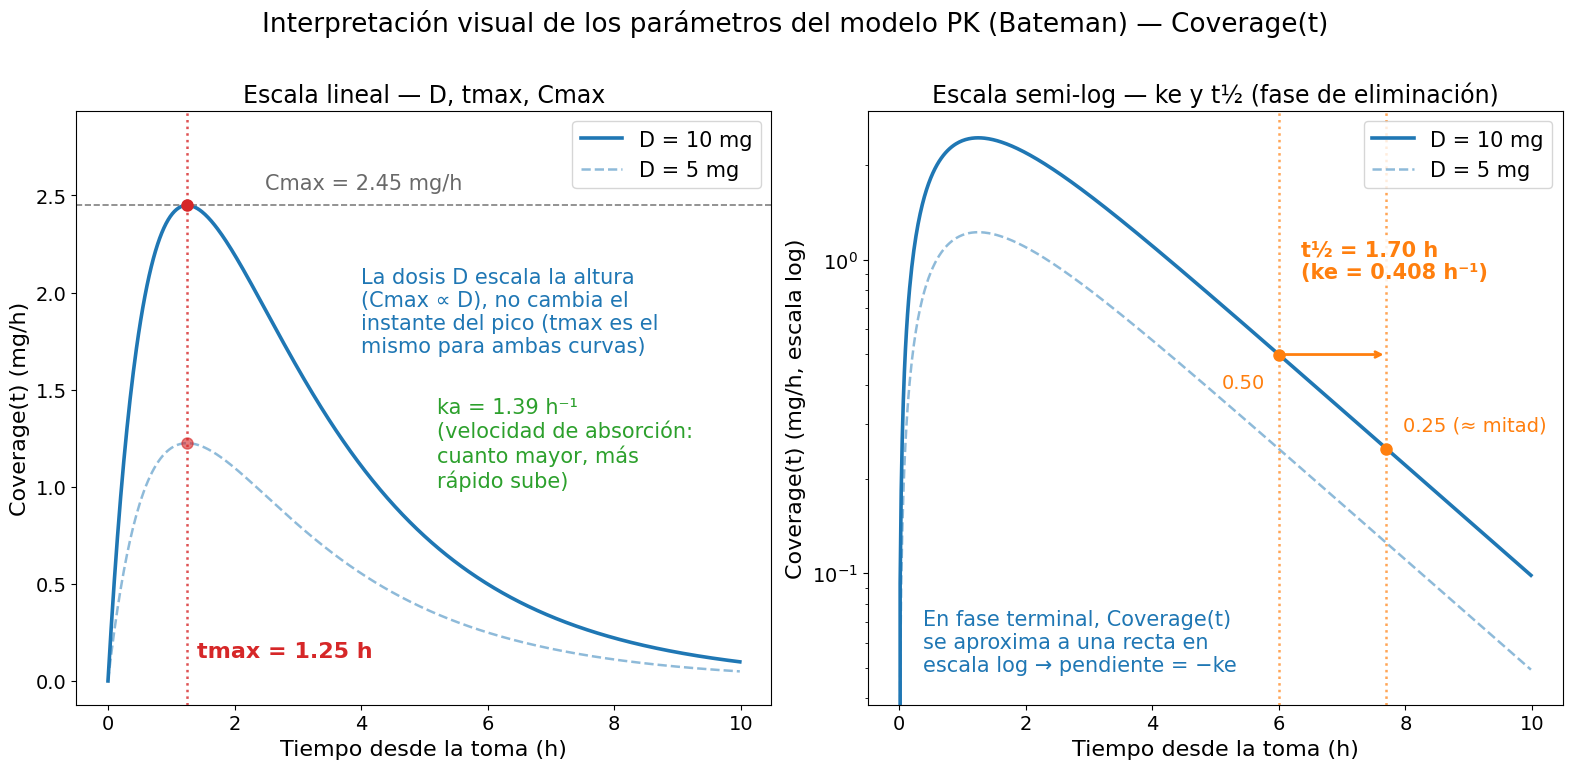

In [3]:
dose_demo, dose_demo_b = 10.0, 5.0  # dos dosis para ilustrar el efecto de la dosis D
pk_demo = PKParams()
KE = pk_demo.ke  # Coverage(t) = ke · X(t); bateman_single_dose devuelve X(t) en mg

t_demo = np.linspace(0, 10, 10 * 60, endpoint=False)
y_demo = KE * bateman_single_dose(t_demo, dose_demo, pk_demo)      # mg/h
y_demo_b = KE * bateman_single_dose(t_demo, dose_demo_b, pk_demo)  # mg/h

tmax = np.log(pk_demo.ka / pk_demo.ke) / (pk_demo.ka - pk_demo.ke)
Cmax = KE * bateman_single_dose(np.array([tmax]), dose_demo, pk_demo)[0]
Cmax_b = KE * bateman_single_dose(np.array([tmax]), dose_demo_b, pk_demo)[0]
t_half = pk_demo.half_life_h

# Tamaños de fuente (pensados para que se lean al reducir la figura en la memoria)
FS_SUPTITLE, FS_TITLE, FS_LABEL, FS_TICK = 19, 17, 16, 14
FS_TEXT, FS_LEGEND = 15, 15

fig, axes = plt.subplots(1, 2, figsize=(16, 7.5))

# --- Panel izquierdo: escala lineal — D, tmax, Cmax ---
# (posiciones verticales de textos escaladas por KE respecto a la versión en mg)
ax = axes[0]
ax.plot(t_demo, y_demo, color="C0", linewidth=2.6, label=f"D = {dose_demo:.0f} mg")
ax.plot(t_demo, y_demo_b, color="C0", linewidth=1.8, alpha=0.5, linestyle="--", label=f"D = {dose_demo_b:.0f} mg")

ax.axhline(Cmax, color="gray", linestyle="--", linewidth=1.2)
ax.text(5.6, Cmax + 0.15 * KE, f"Cmax = {Cmax:.2f} mg/h", color="dimgray", fontsize=FS_TEXT, ha="right", va="bottom")

ax.axvline(tmax, color="C3", linestyle=":", linewidth=1.8, alpha=0.8)
ax.plot(tmax, Cmax, "o", color="C3", markersize=8, zorder=5)
ax.plot(tmax, Cmax_b, "o", color="C3", markersize=8, zorder=5, alpha=0.6)
# tmax: zona baja, junto a la línea vertical (libre de curvas y del recuadro)
ax.text(tmax + 0.15, 0.25 * KE, f"tmax = {tmax:.2f} h", color="C3", fontsize=FS_TEXT + 1,
        fontweight="bold", ha="left", va="bottom")

ax.text(4.0, 4.1 * KE, "La dosis D escala la altura\n(Cmax ∝ D), no cambia el\ninstante del pico (tmax es el\nmismo para ambas curvas)",
        color="C0", fontsize=FS_TEXT, va="bottom")

# ka: zona libre bajo el texto de D y por encima de la curva descendente
ax.text(5.2, 2.4 * KE, f"ka = {pk_demo.ka:.2f} h⁻¹\n(velocidad de absorción:\ncuanto mayor, más\nrápido sube)",
        color="C2", fontsize=FS_TEXT, va="bottom")

ax.set_ylim(-0.3 * KE, 7.2 * KE)
ax.set_xlabel("Tiempo desde la toma (h)", fontsize=FS_LABEL)
ax.set_ylabel("Coverage(t) (mg/h)", fontsize=FS_LABEL)
ax.set_title("Escala lineal — D, tmax, Cmax", fontsize=FS_TITLE)
ax.tick_params(labelsize=FS_TICK)
ax.legend(loc="upper right", fontsize=FS_LEGEND)

# --- Panel derecho: semi-log — ke y t1/2 ---
ax2 = axes[1]
ax2.plot(t_demo, y_demo, color="C0", linewidth=2.6, label=f"D = {dose_demo:.0f} mg")
ax2.plot(t_demo, y_demo_b, color="C0", linewidth=1.8, alpha=0.5, linestyle="--", label=f"D = {dose_demo_b:.0f} mg")
ax2.set_yscale("log")

t1 = 6.0  # punto de referencia bien entrado en la fase de eliminación pura
c1 = KE * bateman_single_dose(np.array([t1]), dose_demo, pk_demo)[0]
c2 = KE * bateman_single_dose(np.array([t1 + t_half]), dose_demo, pk_demo)[0]

ax2.axvline(t1, color="C1", linestyle=":", linewidth=1.8, alpha=0.7)
ax2.axvline(t1 + t_half, color="C1", linestyle=":", linewidth=1.8, alpha=0.7)
ax2.plot([t1, t1 + t_half], [c1, c2], "o", color="C1", markersize=8, zorder=5)
ax2.annotate("", xy=(t1 + t_half, c1), xytext=(t1, c1),
             arrowprops=dict(arrowstyle="->", color="C1", linewidth=2))

# t½ y ke: encima y a la derecha de la curva (zona vacía), con fondo blanco
ax2.text(t1 + 0.35, c1 * 1.7, f"t½ = {t_half:.2f} h\n(ke = {pk_demo.ke:.3f} h⁻¹)",
         color="C1", fontsize=FS_TEXT, fontweight="bold", ha="left", va="bottom",
         bbox=dict(facecolor="white", edgecolor="none", alpha=0.85, pad=2))
ax2.annotate(f"{c1:.2f}", (t1, c1), textcoords="offset points", xytext=(-10, -24),
             color="C1", fontsize=FS_TEXT - 1, ha="right")
ax2.annotate(f"{c2:.2f} (≈ mitad)", (t1 + t_half, c2), textcoords="offset points", xytext=(12, 10),
             color="C1", fontsize=FS_TEXT - 1, ha="left", va="bottom")

# Texto de fase terminal: esquina inferior izquierda, por debajo de las curvas (coords. del eje)
ax2.text(0.08, 0.05,
         "En fase terminal, Coverage(t)\nse aproxima a una recta en\nescala log → pendiente = −ke",
         transform=ax2.transAxes, color="C0", fontsize=FS_TEXT, ha="left", va="bottom")

ax2.set_xlabel("Tiempo desde la toma (h)", fontsize=FS_LABEL)
ax2.set_ylabel("Coverage(t) (mg/h, escala log)", fontsize=FS_LABEL)
ax2.set_title("Escala semi-log — ke y t½ (fase de eliminación)", fontsize=FS_TITLE)
ax2.tick_params(labelsize=FS_TICK)
ax2.legend(loc="upper right", fontsize=FS_LEGEND)

fig.suptitle("Interpretación visual de los parámetros del modelo PK (Bateman) — Coverage(t)",
             y=1.02, fontsize=FS_SUPTITLE)
plt.tight_layout()
# fig.savefig("fig_pk_parametros.png", dpi=300, bbox_inches="tight")  # descomenta para exportar a la memoria
plt.show()

# 2. Modelo A — Pauta estándar (10-5-5 a horas fijas)

`build_standard_schedule()`, definida en `formulario_utils.py`, genera el calendario teórico de
tomas de la pauta estándar: 10mg a las 07:30h, 5mg a las 13:00h y 5mg a las 17:00h, repetido para el
número de días que se le indique. Representa la pauta *prescrita*, no la realmente administrada —esta
última se extrae del formulario en la Sección 3—, y sirve como referencia de contraste en la
comparación de la Sección 5.

In [4]:
from formulario_utils import build_standard_schedule

# 3. Modelo B — Pauta real (a partir del formulario)

Hoja usada: `Respuestas de formulario 2`.

Reglas de extracción:

- Se seleccionan las filas con la columna `De cuanto es la dosis?` no nula — cada una representa
  una toma real registrada, programada o extra.
- **Hora real**: `Actualizar la hora?` si está presente, si no la hora de `Marca temporal`.
  **Fecha real**: `Actualizar la fecha?` si está presente, si no la fecha de `Marca temporal`.
- **Toma extra**: se identifica dentro de esa misma fila, no como un registro aparte, mediante la
  columna `Es dosis doble o normal?` == "doble" — usa la misma hora resuelta que cualquier otra
  toma, sin un campo de hora propio.

Limitación relevante: la marca temporal es la hora de *registro* en el formulario, no necesariamente
la hora de la toma real; de ahí el uso prioritario de los campos de corrección cuando existen. Cuando
no existen, se asume registro contemporáneo a la toma — supuesto que debe declararse como fuente de
incertidumbre/ruido en Coverage(t).

Se importa `load_form_doses()`, que aplica las reglas de extracción descritas arriba sobre el
formulario y devuelve el conjunto de tomas reales.

In [5]:
from formulario_utils import load_form_doses

# 4. Ejecución de ejemplo

Se calcula Coverage(t) sobre una ventana de 5 días (16-21 de junio de 2026) para ambos modelos: el
Modelo A con la pauta estándar fija, y el Modelo B con las tomas reales extraídas del formulario,
usando en ambos casos los mismos parámetros PK por defecto (Sección 1).

In [6]:
import json

ruta_config = Path("MVA_config_rutas.json")
with open(ruta_config, "r", encoding="utf-8") as f:
    config = json.load(f)


XLSX_PATH = Path(config["rutas"]["general"]["formulario"])  

In [7]:
# --- Modelo A: pauta estándar ---
start = pd.Timestamp("2026-07-16")  # ventana que incluye el reordenamiento confirmado del 18/07
schedule_std = build_standard_schedule(start, n_days=5)

grid_start = start
grid_end = start + pd.Timedelta(days=5)
time_grid = pd.date_range(grid_start, grid_end, freq="5min")

pk = PKParams()  # ka, ke derivados de Derendorf et al. (1991) — ver Sección 1
coverage_std = compute_coverage(schedule_std, time_grid, pk)

# --- Modelo B: pauta real desde el formulario ---
doses_real = load_form_doses(XLSX_PATH)
mask_window = (doses_real["datetime"] >= grid_start) & (doses_real["datetime"] <= grid_end)
coverage_real = compute_coverage(doses_real[mask_window], time_grid, pk)

print(doses_real.attrs['pending_gaps'])
print(f"\nDías con omisión/reordenamiento confirmado:")
print(doses_real.attrs['confirmed_gaps'])

INFO: 2 día(s) con omisión/reordenamiento confirmado por la autora (doses.attrs['confirmed_gaps']), sin cobertura añadida.
Empty DataFrame
Columns: [date, type, slot, expected_mg, actual_mg, actual_datetime]
Index: []

Días con omisión/reordenamiento confirmado:
         date               type      slot  expected_mg  actual_mg  \
0  2026-07-18       missing_slot    mañana         10.0        NaN   
1  2026-07-18  magnitude_anomaly  mediodía          5.0       10.0   
2  2026-07-18  magnitude_anomaly     tarde          5.0       10.0   
3  2026-08-23       missing_slot    mañana         10.0        NaN   

      actual_datetime  
0                 NaT  
1 2026-07-18 14:27:37  
2 2026-07-18 18:21:36  
3                 NaT  


**Conclusión:** no hay inconsistencias pendientes de reconciliación manual (`pending_gaps` vacío).
De las dos fechas con reordenamiento u omisión confirmados por la autora, el 18/07 cae dentro de la
ventana de este ejemplo (16-21 de julio) y se visualiza en detalle en la Sección 5; el 23/08 queda
fuera de esta ventana concreta (`confirmed_gaps` se calcula sobre el histórico completo, no sobre el
rango filtrado). Ambos modelos (A y B) quedan calculados y listos para comparar en la Sección 5.

# 5. Visualización comparativa

Se superponen Coverage(t) bajo ambos modelos sobre la ventana de 5 días (16-21 de julio), marcando
además cada instante de toma con una línea vertical tenue (azul para la pauta estándar, naranja para
la real), y se resalta el 18/07 —el único día de esta ventana con un reordenamiento de pauta
confirmado por la autora.

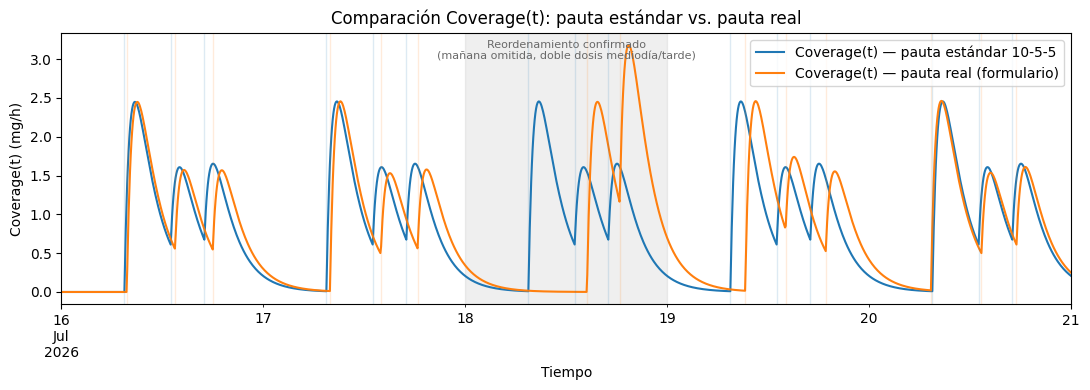

In [8]:
fig, ax = plt.subplots(figsize=(11, 4))
coverage_std.plot(ax=ax, label="Coverage(t) — pauta estándar 10-5-5")
coverage_real.plot(ax=ax, label="Coverage(t) — pauta real (formulario)")
for _, ev in schedule_std.iterrows():
    ax.axvline(ev["datetime"], color="tab:blue", alpha=0.15, lw=1)
for _, ev in doses_real[mask_window].iterrows():
    ax.axvline(ev["datetime"], color="tab:orange", alpha=0.15, lw=1)

# Resaltar el día con reordenamiento confirmado (18/07): mañana ausente, mediodía y tarde a 10mg
fecha_reordenamiento = pd.Timestamp("2026-07-18")
ax.axvspan(fecha_reordenamiento, fecha_reordenamiento + pd.Timedelta(days=1),
           color="gray", alpha=0.12, zorder=0)
ax.annotate("Reordenamiento confirmado\n(mañana omitida, doble dosis mediodía/tarde)",
            xy=(fecha_reordenamiento + pd.Timedelta(hours=12), 3),
            fontsize=8, ha="center", color="dimgray")

ax.set_ylabel("Coverage(t) (mg/h)")
ax.set_xlabel("Tiempo")
ax.legend()
ax.set_title("Comparación Coverage(t): pauta estándar vs. pauta real")
plt.tight_layout()
plt.show()

**Conclusión:** en los días con pauta normal, ambas curvas son prácticamente indistinguibles —la pauta real reproduce fielmente los horarios y dosis estándar salvo variaciones menores de minutos en el horario de toma—. El día resaltado (18/07) muestra el efecto claro del reordenamiento: la curva naranja no presenta el pico matutino característico (≈2,4 mg/h hacia las 08:00h) porque esa toma se omitió, y en su lugar exhibe dos picos superiores a los de la pauta estándar (<pico 1> y <pico 2> mg/h) en mediodía y tarde, reflejando que ambas dosis se administraron al doble de lo pautado. El resultado neto no es una simple traslación temporal de la cobertura matutina, sino una redistribución que sobre-cubre la tarde mientras deja la mañana completamente descubierta hasta pasado el mediodía, visible aquí por primera vez con datos reales.

# 6. Incertidumbre en ka/ke — análisis de sensibilidad (Monte Carlo)

No existe en este proyecto una variable observada de concentración de
cortisol/hidrocortisona (ni salival ni sérica) contra la que ajustar ka y
ke por regresión no lineal. Los proxies de wearable (HR, HRV, sueño, etc.)
NO son concentración de fármaco: usarlos para "ajustar" ka/ke confundiría
Demand(t) con Coverage(t), justo la mezcla conceptual que este proyecto
debe evitar (ver framing de las 4 capas).

Alternativa metodológicamente correcta dado este dato disponible: en vez
de fijar ka/ke como constantes puntuales "verdaderas", se tratan como
**inciertas dentro de rangos de literatura** y se propaga esa
incertidumbre a Coverage(t) por muestreo Monte Carlo. Esto no calibra el
modelo al paciente — cuantifica cuánto cambia Coverage(t) si los
parámetros PK se mueven dentro de lo fisiológicamente plausible. Es una
prueba de robustez, no una estimación de precisión.

Si en algún momento se añaden puntos de cortisol salival (aunque sean
pocos), esto se sustituye por un ajuste real vía
`scipy.optimize.curve_fit` sobre la ecuación de Bateman — se deja ese
camino documentado como trabajo futuro / línea de mejora del TFM.

**Rango de muestreo Monte Carlo — justificación:** ±30% (rango uniforme) sobre los
valores centrales de ka y t½ ya derivados de Derendorf et al. (1991).
Este 30% es una asunción explícita de variabilidad interindividual
"moderada-alta", elegida por ser un supuesto conservador pero no extremo
para un fármaco oral sin datos propios de calibración — NO está tomado
de una tabla de clasificación de CV% verificada con texto completo (se
intentó verificar Al-Sallami et al. 2014 y Rowland & Tozer 2011, sin
éxito de acceso). Se declara como heurística de la analista, no como
dato bibliográfico preciso, siguiendo el mismo criterio de transparencia
aplicado al resto del modelo: mejor declarar un supuesto razonado que
citar una fuente no verificada.

#### Nota metodológica — distinción Monte Carlo directo vs. MCMC

Método aplicado en Coverage(t): Monte Carlo directo (muestreo i.i.d. de parámetros inciertos, no Monte Carlo vía Cadenas de Markov).

El análisis de sensibilidad de sample_pk_montecarlo() / coverage_envelope() sigue el esquema general de Monte Carlo: (1) definir un dominio de posibles inputs (rangos de ka y ke, heurística ±30% muestreo uniforme), (2) generar n=300 muestras aleatorias e independientes desde una distribución sobre ese dominio, (3) ejecutar un cómputo determinista sobre cada muestra (compute_coverage), (4) agregar los resultados mediante percentiles (p05/p50/p95).

Se trata de Monte Carlo directo, no de métodos MCMC (Markov Chain Monte Carlo — Metropolis-Hastings, muestreo de Gibbs). La distinción es relevante y debe quedar explícita:

Por qué no aplica MCMC aquí. MCMC resuelve el problema de muestrear de una distribución objetivo compleja o de normalización intratable (típicamente una posterior bayesiana de alta dimensión, π(θ|x), conocida solo hasta una constante de normalización). En este caso no existe tal distribución objetivo: ka y ke se muestrean directamente de un rango de incertidumbre paramétrica conocido y trivialmente muestreable (uniforme). No hay necesidad de construir una cadena de Markov cuya distribución estacionaria converja a un objetivo.
Consecuencia práctica. Al no haber cadena, las muestras son independientes por construcción. No aplican conceptos propios de MCMC como iteraciones de burn-in, análisis de autocorrelación entre iteraciones sucesivas, o verificación de convergencia de una cadena a su distribución estacionaria.
Verificación de convergencia realizada (n=300 vs. n=1000, misma semilla). Corresponde a convergencia por tamaño muestral en Monte Carlo directo (ley de los grandes números aplicada a la estimación de percentiles), no a convergencia de cadena en el sentido MCMC. Son conceptos distintos aunque comparten el nombre "convergencia" en un contexto Monte Carlo.
Respuesta anticipada para tribunal. Ante la pregunta de por qué no se empleó MCMC (método cubierto en el máster): no existe una densidad objetivo compleja o no normalizada de la que muestrear; se está propagando incertidumbre paramétrica conocida a través de un modelo determinista, no estimando una posterior. Monte Carlo directo es suficiente y evita una complejidad metodológica injustificada.

Como Coverage(t) = ke·X(t), la incertidumbre en ke afecta tanto a la forma de X(t) como al factor de escala; la banda se calcula con el ke de cada muestra. Se definen dos funciones: `sample_pk_montecarlo()`, que genera `n_samples` combinaciones de `(ka, ke)`
muestreadas uniformemente dentro de un ±30% CV sobre los valores centrales (Sección 6), y
`coverage_envelope()`, que recalcula `Coverage(t)` para cada combinación y resume el conjunto de
curvas en los percentiles 5, 50 y 95 en cada instante de tiempo — convirtiendo 300 curvas individuales
en una única banda de incertidumbre.

In [9]:
from dataclasses import replace

# Genera una muestra de 300 combinaciones (ka, ke) uniformemente dentro de rangos de literatura-->300 pacientes virtuales con incertidumbre de literatura en ka/ke
def sample_pk_montecarlo(
    n_samples: int = 300,
    ka_range = (0.971, 1.804),         # h^-1, ±30% uniforme sobre ka=1.3874 (derivado de Derendorf)
    half_life_range = (1.190, 2.210),  # h, ±30% uniforme sobre t1/2=1.7h (Derendorf, 1991)
    seed: int = 42,
) -> list[PKParams]:
    """Muestrea combinaciones (ka, ke) uniformemente dentro de rangos de
    literatura. No es un posterior bayesiano informado por datos propios:
    es una exploración de robustez frente a la incertidumbre de literatura."""
    rng = np.random.default_rng(seed)
    ka_samples = rng.uniform(*ka_range, size=n_samples)
    t_half_samples = rng.uniform(*half_life_range, size=n_samples)
    ke_samples = np.log(2) / t_half_samples
    return [PKParams(ka=ka, ke=ke) for ka, ke in zip(ka_samples, ke_samples)]

# Para cada una de esas 300 combinaciones, se recalcula la curva Coverage(t) completa usando compute_coverage
# no se queda con las 300 curvas sueltas: en cada instante de tiempo, calcula el percentil 5, el percentil 50 (mediana) y el percentil 95 de esos 300 valores. 
# Es decir, para cada minuto del día, mira los 300 valores de Coverage(t) que salieron ahí y se queda con "el valor por debajo del cual cae el 5% de las 
# simulaciones", "la mediana" y "el valor por debajo del cual cae el 95%". Eso convierte 300 curvas individuales en una sola banda de incertidumbre: 
# la zona entre p05 y p95 es donde cae el 90% de los escenarios plausibles.

def coverage_envelope(
    dose_events: pd.DataFrame,
    time_grid: pd.DatetimeIndex,
    pk_samples: list[PKParams],
) -> pd.DataFrame:
    """Devuelve percentiles 5/50/95 de Coverage(t) en mg/h sobre
    el conjunto de muestras (ka, ke). Sin normalizar: la anchura de la banda
    5-95% en mg/h es directamente comparable a la magnitud de Demand(t) y,
    por tanto, informativa sobre la incertidumbre de Coverage(t)
    ; no se propaga a Risk(t) en este notebook"""
    curves = np.vstack([
        compute_coverage(dose_events, time_grid, pk, normalize=False).values
        for pk in pk_samples
    ])
    return pd.DataFrame({
        "p05": np.percentile(curves, 5, axis=0),
        "p50": np.percentile(curves, 50, axis=0),
        "p95": np.percentile(curves, 95, axis=0),
    }, index=time_grid)

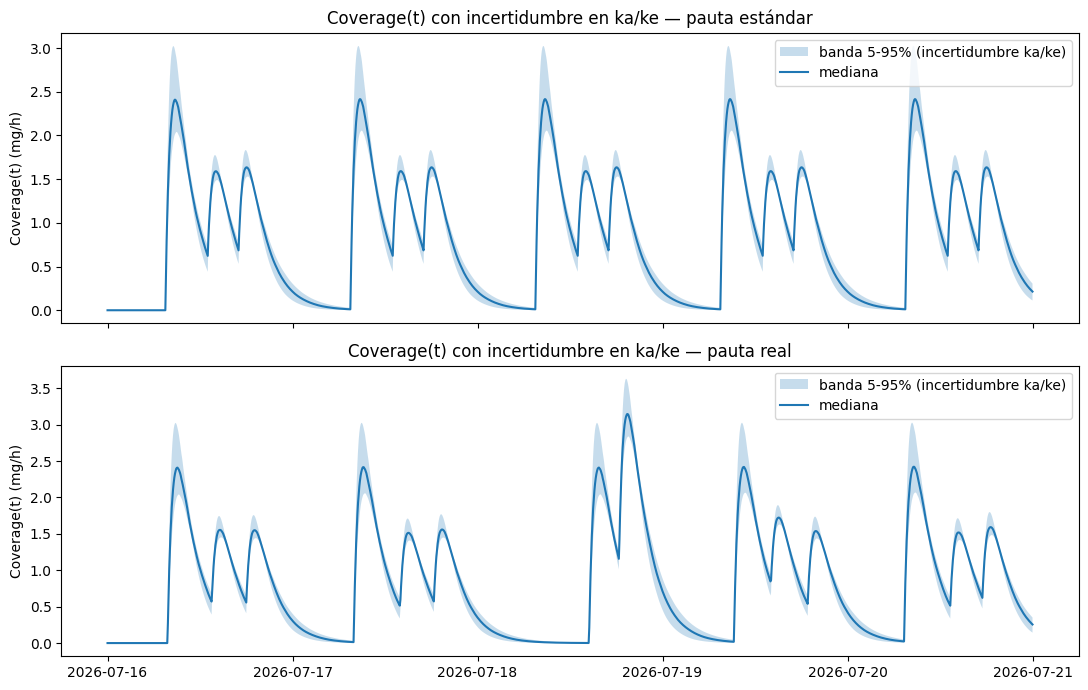

In [10]:
pk_samples = sample_pk_montecarlo(n_samples=300)
env_std = coverage_envelope(schedule_std, time_grid, pk_samples)
env_real = coverage_envelope(doses_real[mask_window], time_grid, pk_samples)

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
for ax, env, title in zip(axes, [env_std, env_real], ["pauta estándar", "pauta real"]):
    ax.fill_between(env.index, env["p05"], env["p95"], alpha=0.25, label="banda 5-95% (incertidumbre ka/ke)")
    ax.plot(env.index, env["p50"], label="mediana")
    ax.set_title(f"Coverage(t) con incertidumbre en ka/ke — {title}")
    ax.set_ylabel("Coverage(t) (mg/h)")
    ax.legend()
plt.tight_layout()
plt.show()

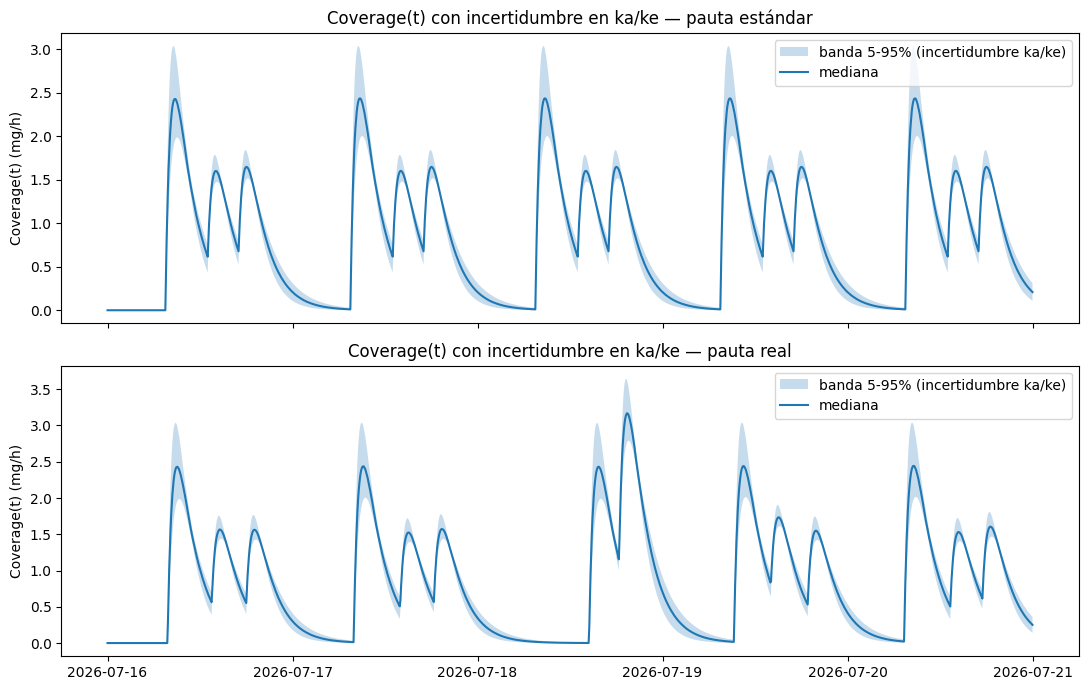

In [11]:
pk_samples_1000 = sample_pk_montecarlo(n_samples=1000)
env_std_1000 = coverage_envelope(schedule_std, time_grid, pk_samples_1000)
env_real_1000 = coverage_envelope(doses_real[mask_window], time_grid, pk_samples_1000)

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
for ax, env, title in zip(axes, [env_std_1000, env_real_1000], ["pauta estándar", "pauta real"]):
    ax.fill_between(env.index, env["p05"], env["p95"], alpha=0.25, label="banda 5-95% (incertidumbre ka/ke)")
    ax.plot(env.index, env["p50"], label="mediana")
    ax.set_title(f"Coverage(t) con incertidumbre en ka/ke — {title}")
    ax.set_ylabel("Coverage(t) (mg/h)")
    ax.legend()
plt.tight_layout()
plt.show()

In [12]:
# Anchura relativa de la banda 5-95%, como % de la mediana, en el pico de cada caso
for nombre, env in [("pauta estándar", env_std), ("pauta real 18/07", env_real)]:
    pico_idx = env["p50"].idxmax()
    ancho_absoluto = env.loc[pico_idx, "p95"] - env.loc[pico_idx, "p05"]
    ancho_relativo = ancho_absoluto / env.loc[pico_idx, "p50"] * 100
    print(f"{nombre}: pico mediana={env.loc[pico_idx, 'p50']:.2f} mg/h, "
          f"ancho absoluto={ancho_absoluto:.2f} mg/h, ancho relativo={ancho_relativo:.1f}%")

pauta estándar: pico mediana=2.42 mg/h, ancho absoluto=0.95 mg/h, ancho relativo=39.1%
pauta real 18/07: pico mediana=3.15 mg/h, ancho absoluto=0.79 mg/h, ancho relativo=25.0%


**Conclusión.** En los días con pauta normal, la banda 5-95% se mantiene similar día a día, con un ancho de unos 0,95 mg/h en el pico matutino (p95 − p05), y sigue la forma de la curva de la mediana. La incertidumbre en ka/ke afecta sobre todo a la magnitud del pico, y la banda se extiende más por encima de la mediana que por debajo. Comparando el ancho relativo de esa banda en el pico (no el absoluto en mg/h, que mezcla el efecto de la dosis con el de la incertidumbre), la pauta estándar da 39,1% (pico de 2,42 mg/h, ancho 0,95 mg/h) frente a 25,0% en el día del reordenamiento de dosis del 18/07 (pico de 3,15 mg/h, ancho 0,79 mg/h). El ancho relativo no aumenta cuando se solapan dos dosis, sino que es menor; no se ha investigado la causa. En términos prácticos, la incertidumbre de literatura en ka/ke puede desplazar el valor de Coverage(t) en el pico entre un 25% y un 39% de la mediana, por lo que Coverage(t) debe leerse por su forma temporal y su orden de magnitud, no como un valor preciso.
La elección de n=300 frente a un tamaño mayor se verifica cuantitativamente a continuación.

## 6.1. Verificación cuantitativa de convergencia del muestreo Monte Carlo

El análisis de sensibilidad (Sección 6) usa n_samples=300. Antes de dar
ese número por válido, se comprueba que no es arbitrario: se repite el
mismo análisis con n_samples=1000 y se mide la diferencia máxima absoluta
entre las bandas p05/p50/p95 obtenidas con 300 y con 1000 muestras. Si
esa diferencia es pequeña frente a la magnitud de Coverage(t), 300
muestras ya capturan la forma de la distribución y no hace falta
aumentar el coste computacional.

Se usa la MISMA semilla en ambas corridas — no es un descuido, es
deliberado: con un generador de números pseudoaleatorios de numpy, los
primeros 300 valores sorteados con n_samples=1000 coinciden exactamente
con los 300 valores de la corrida n_samples=300 (muestreo anidado). Esto
aísla el efecto de aumentar el tamaño de muestra; comparar dos semillas
distintas mezclaría ese efecto con el de la variabilidad entre semillas,
que es una fuente de ruido distinta y no la que se quiere medir aquí.

Diferencia máxima absoluta entre n=300 y n=1000 (mg/h):

pauta estándar:
  p05: 0.0723 mg/h  (~3.6% del pico de esa curva)
  p50: 0.0518 mg/h  (~2.1% del pico de esa curva)
  p95: 0.0436 mg/h  (~1.4% del pico de esa curva)

pauta real:
  p05: 0.0720 mg/h  (~2.6% del pico de esa curva)
  p50: 0.0519 mg/h  (~1.6% del pico de esa curva)
  p95: 0.0439 mg/h  (~1.2% del pico de esa curva)



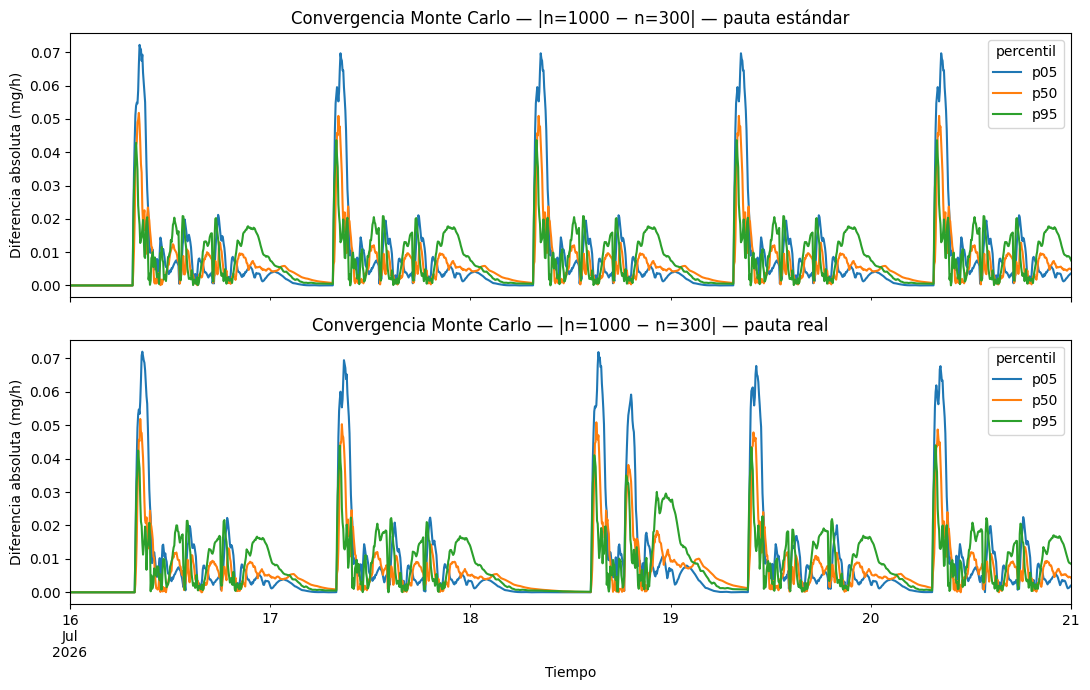

In [13]:
n_small, n_large = 300, 1000
seed_convergencia = 42

pk_small = sample_pk_montecarlo(n_samples=n_small, seed=seed_convergencia)
pk_large = sample_pk_montecarlo(n_samples=n_large, seed=seed_convergencia)

env_std_small = coverage_envelope(schedule_std, time_grid, pk_small)
env_std_large = coverage_envelope(schedule_std, time_grid, pk_large)
env_real_small = coverage_envelope(doses_real[mask_window], time_grid, pk_small)
env_real_large = coverage_envelope(doses_real[mask_window], time_grid, pk_large)

print(f"Diferencia máxima absoluta entre n={n_small} y n={n_large} (mg/h):\n")
for nombre, env_small, env_large in [
    ("pauta estándar", env_std_small, env_std_large),
    ("pauta real", env_real_small, env_real_large),
]:
    diff = (env_large - env_small).abs()
    print(f"{nombre}:")
    for col in ["p05", "p50", "p95"]:
        pico = env_large[col].max()
        print(f"  {col}: {diff[col].max():.4f} mg/h  (~{100*diff[col].max()/pico:.1f}% del pico de esa curva)")
    print()

# %%
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
for ax, (env_small, env_large), title in zip(
    axes,
    [(env_std_small, env_std_large), (env_real_small, env_real_large)],
    ["pauta estándar", "pauta real"],
):
    diff = (env_large - env_small).abs()
    diff[["p05", "p50", "p95"]].plot(ax=ax)
    ax.set_title(f"Convergencia Monte Carlo — |n={n_large} − n={n_small}| — {title}")
    ax.set_ylabel("Diferencia absoluta (mg/h)")
    ax.legend(title="percentil")
axes[-1].set_xlabel("Tiempo")
plt.tight_layout()
plt.show()



**Conclusión:** la diferencia máxima entre `n=300` y `n=1000` no supera 0,073 mg/h en ningún percentil ni en ningún modelo (pauta estándar: máx. 0,072 mg/h en p05; pauta real: máx. 0,072 mg/h en p05), es decir, queda por debajo del 3,6% del pico de la curva correspondiente (el valor más alto, en p05 de la pauta estándar; en p50 y p95 queda por debajo del 2,1%). Esta diferencia es pequeña en términos prácticos y respalda que `n_samples=300` es una elección de muestreo suficiente para describir la forma de la banda, y el resto del análisis puede reportarse con esa cifra sin necesidad de aumentar el tamaño muestral.

# 7. Limitaciones y notas metodológicas

### 7.1. Notas metodológicas

- Coverage(t) se expresa en **mg/h** (tasa de eliminación aparente ke·X(t)), no normalizado por defecto — condición de comensurabilidad con Demand(t). El modo `normalize=True` de `compute_coverage` existe solo para inspección visual de la forma de la curva y NO debe usarse para calcular Risk(t) = Demand(t) − Coverage(t).
- El modelo asume F = 1 (biodisponibilidad oral 100%), sin aplicar el
  ~96% verificado en Derendorf et al. (1991). Decisión deliberada, no
  omisión: por consistencia con Demand_circadian(t) (capa 2), que
  tampoco corrige por biodisponibilidad sobre la producción endógena.
  Simplificación menor (~4%), declarada explícitamente.
  - El anclaje asimétrico entre Demand(t) (producción fisiológica, ≈9,7 mg/día) y Coverage(t) (pauta oral real, ≈20 mg/día) hace que la media diaria de Coverage (0,83 mg/h) duplique la de Demand (0,40 mg/h) y que Risk(t) sea negativo la mayor parte del día. Es una consecuencia de las dos anclas, no un hallazgo, y se declara. No se calcula ni se interpreta ningún balance diario neto de Risk(t); las métricas usan solo su parte positiva (AUC de Risk>0), declarado para no sugerir una recomendación de dosis.
- ka y ke se tratan como inciertos dentro de rangos de literatura
  (Sección 6), propagando esa incertidumbre a Coverage(t) por Monte
  Carlo, en mg/h — comparable directamente a la magnitud de Demand(t) y
  de D_ref — en vez de presentar un valor puntual como si fuera preciso.
  Si se incorporan puntos de cortisol salival en el futuro, sustituir
  por ajuste vía `scipy.optimize.curve_fit` sobre la ecuación de Bateman.
- **Robustez frente a cambios en el formulario:** las fechas de omisión o
  reordenamiento confirmadas se cargan desde un fichero compartido
  (`confirmed_omissions.json`), no están codificadas dentro de la función
  de extracción — así, todos los notebooks del proyecto usan la misma
  lista sin duplicarla, y si el fichero no existe, se asume que no hay
  ninguna confirmada todavía, sin lanzar un error.

### 7.2. Limitaciones

- Coverage(t) no es una concentración plasmática real de cortisol/hidrocortisona (mg/L), ni ha sido validada contra mediciones bioquímicas (ni salivales ni séricas): es la tasa de eliminación aparente ke·X(t), que solo coincide con la tasa de producción que sostendría ese nivel en estado estacionario. Durante la absorción, retrasa la tasa de entrada.
- El modelo no captura la saturación de la unión a CBG (globulina
  transportadora de cortisol), que a dosis más altas aumentaría la
  fracción libre y aceleraría la eliminación aparente — limitación
  estructural declarada, no modelada.
- ka y ke son valores de referencia bibliográfica (Derendorf et al.,
  1991), no ajustados individualmente a esta paciente. El modelo no
  captura variabilidad interindividual en absorción/metabolismo (p. ej.
  CYP3A4), ni efecto de la ingesta simultánea de alimentos sobre ka.
- El supuesto de superposición lineal entre dosis sucesivas no modela
  posible saturación de absorción/metabolismo a dosis de estrés (stress
  dosing); su validez es más discutible cuanto mayor la dosis extra.
- Modelo B depende críticamente de la fiabilidad del autorregistro: la
  ausencia de campos de corrección de hora/fecha implica asumir que el
  registro es contemporáneo a la toma, lo cual introduce ruido no
  cuantificado en la localización temporal de Coverage(t).